## Extra Project Clash Royale Emote Detection

To train my facial expressions and hand gestures and landmarks I had to manually track:
- Left Hand Gesture (lhg) ✅
- Right Hand Gesture (rhg) ✅
- The 52 facial bendshapes  ✅
- The 20 left finger landmarks * 2  ✅
- The 20 right finger landmarks * 2  ✅

135 Landmarks total landmarks, proudly I made a script which captures and process such landmarks, achieving the impressive mark of +7300 data registers which are map to the following clash royale emotes:
1. "Thumbs_Up_Goblin",
2. "Yawning_Princess",
3. "Goblin_Peace_Sign",
4. "Angry_Barb",
5. "Magician_Fire",
6. "Surprised_Bandit"

And I already know I may be overengineering a problem for just 6 emotes but I want a scalable way to justify the 130 landmarks registered

### Setting Up the notebook

In [2]:
# Basic imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('./processed_emotes.csv')
df.head()

,lhg,rhg,browDownLeft,browDownRight,browInnerUp,browOuterUpLeft,browOuterUpRight,cheekPuff,cheekSquintLeft,cheekSquintRight,...,rl16y,rl17x,rl17y,rl18x,rl18y,rl19x,rl19y,rl20x,rl20y,emote_label
0,5.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.002066,0.052040,-0.012738,0.074273,-0.024310,0.063033,-0.028449,0.052363,-0.025021,0.0
1,5.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.014709,0.057008,-0.003830,0.079817,-0.010499,0.068619,-0.014962,0.057075,-0.012675,0.0
2,5.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.012013,0.056318,-0.011885,0.079261,-0.015398,0.067915,-0.018609,0.055864,-0.016395,0.0
3,5.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.016788,0.058696,-0.005283,0.080445,-0.008273,0.070046,-0.012470,0.059024,-0.010567,0.0
4,5.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.004885,0.057892,-0.016041,0.077931,-0.021632,0.067540,-0.024059,0.057594,-0.020375,0.0


In [4]:
df.describe()

,lhg,rhg,browDownLeft,browDownRight,browInnerUp,browOuterUpLeft,browOuterUpRight,cheekPuff,cheekSquintLeft,cheekSquintRight,...,rl16y,rl17x,rl17y,rl18x,rl18y,rl19x,rl19y,rl20x,rl20y,emote_label
count,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.0,7352.0,7352.0,...,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000
mean,1.538493,1.446817,0.032198,0.028764,0.027079,0.030555,0.030205,0.0,0.0,0.0,...,0.079407,0.012951,0.045766,0.026685,0.059025,0.029556,0.058489,0.029264,0.060224,2.488847
std,2.164790,2.119129,0.142124,0.132465,0.132211,0.140097,0.139404,0.0,0.0,0.0,...,0.099986,0.032374,0.055821,0.040269,0.071167,0.038322,0.079273,0.037581,0.088794,1.738874
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,-0.114026,-0.075752,-0.124520,-0.097516,-0.118904,-0.091121,-0.133864,-0.100833,-0.136494,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,0.000000,-0.004995,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,0.055377,0.000000,0.048356,0.011869,0.059924,0.017251,0.049736,0.016483,0.043519,3.000000
75%,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,0.110308,0.036701,0.096215,0.054653,0.115446,0.056080,0.095846,0.053042,0.087344,4.000000
max,6.000000,6.000000,0.994204,0.926214,0.995865,0.975660,0.956323,0.0,0.0,0.0,...,0.498099,0.186798,0.206933,0.229629,0.313802,0.201553,0.380782,0.197271,0.431386,5.000000


### Surface Data Analysis
I could make a graph for each feature of the data set, but I'll just graph the most visual and important features

**Left and right hand gestures**

Using mediapipe [Hand Gesture Recognition Model](https://ai.google.dev/edge/mediapipe/solutions/vision/gesture_recognizer). I managed to detect the gestures or none that I was making.

As you can see in the graphs the predominant gesture is None, since some emotes don't necessarily need a detected gesture

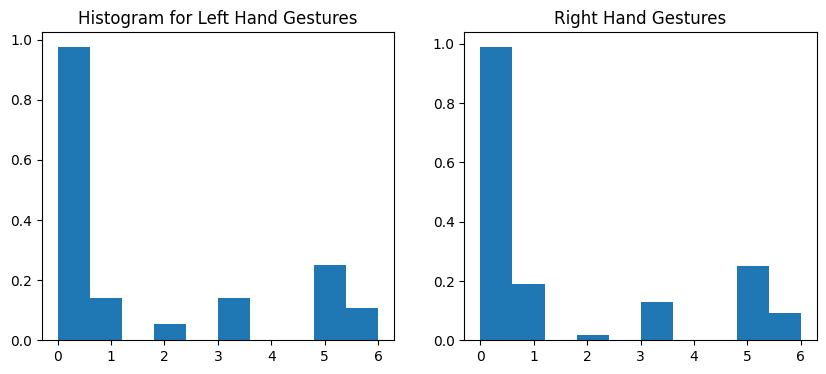

In [5]:
# Left and right hand gestures
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.hist(df['lhg'], density=True)
ax1.set_title("Histogram for Left Hand Gestures")
ax2.hist(df['rhg'], density=True)
ax2.set_title("Right Hand Gestures")
plt.show()

**Face Blendshape**

Using mediapipe [Hand Face Landmark Recognition Model](https://ai.google.dev/edge/mediapipe/solutions/vision/face_landmarker). I managed to detect the face gestures or none that I was making.

Here I commited a rookie mistake, I dismissed every facial expression with less accuracy than 50% to avoid noise, and it make sense but I should have left the data processing to this part. But what can I say I'm still a rookie and just getting my hands on this kind of work

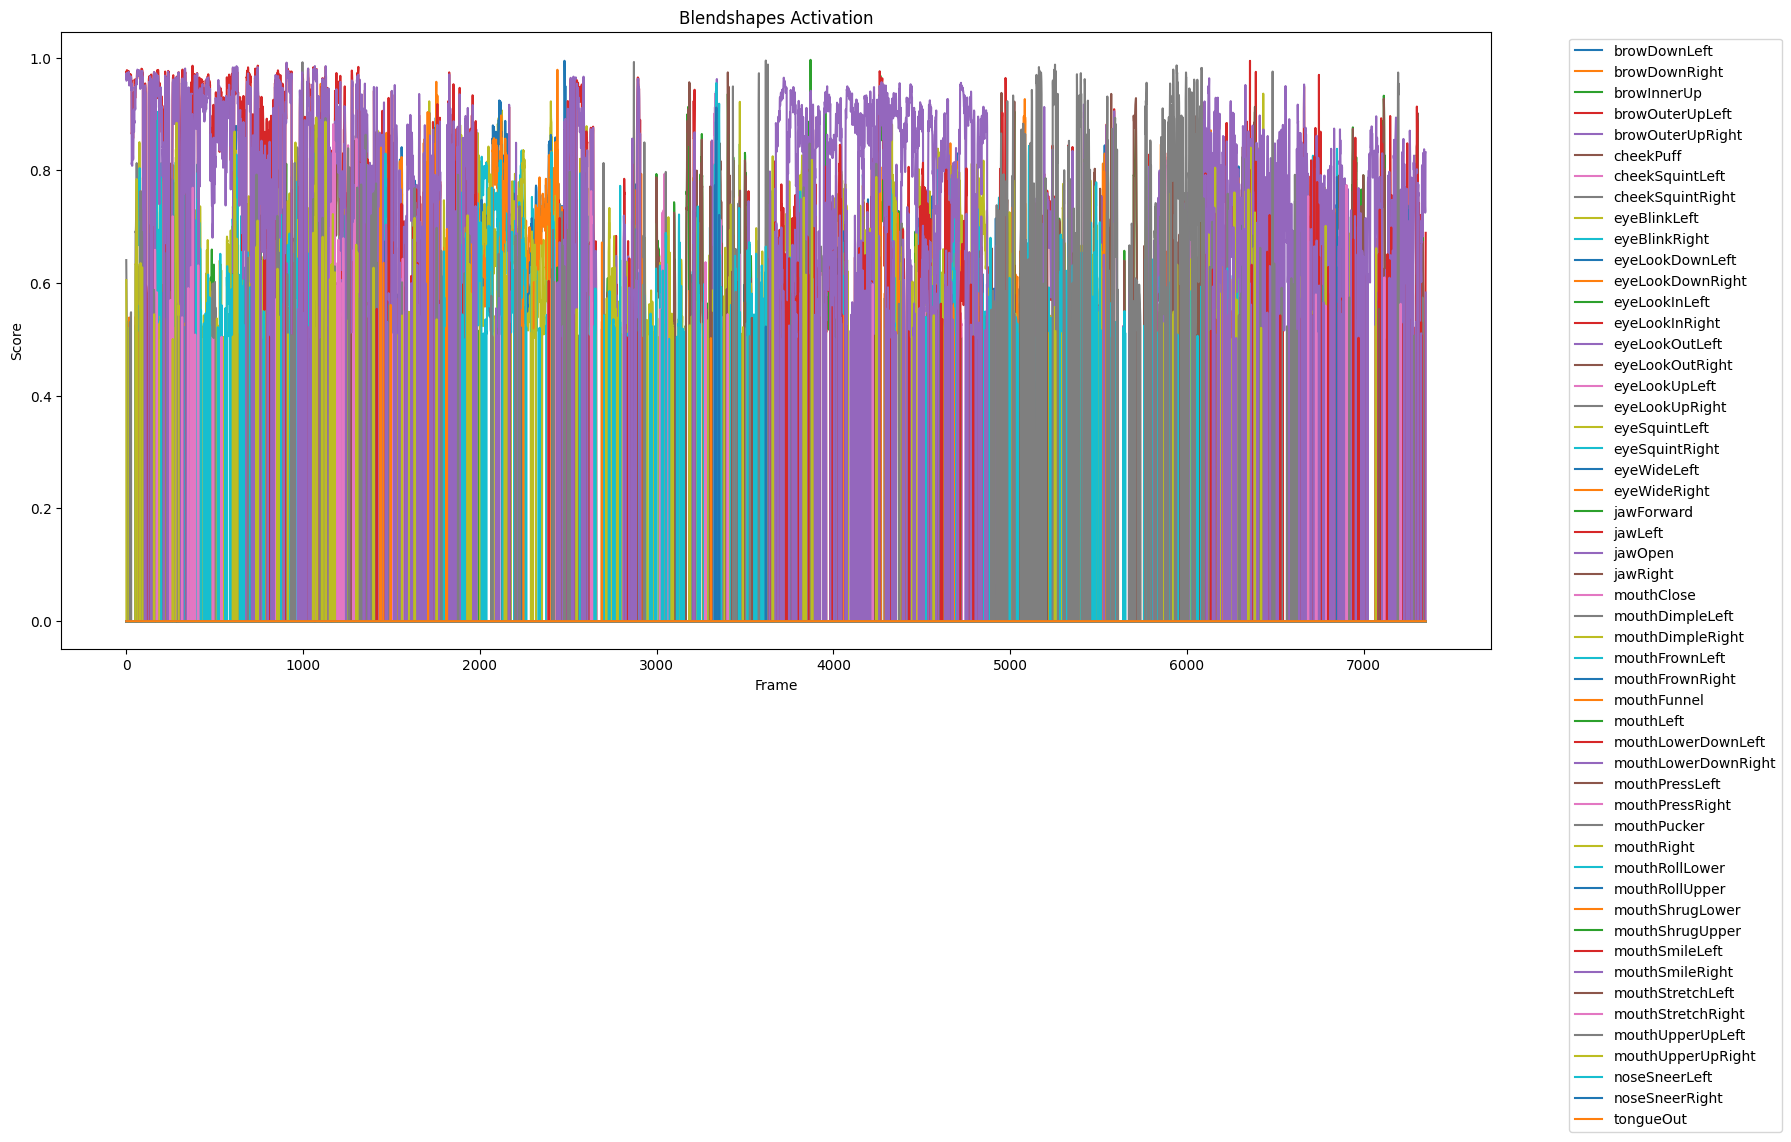

In [9]:
# Face Blendshape
plt.figure(figsize=(18, 10))

for c, column in enumerate(df.columns):
    if c < 2 or c > 53:
        continue
    else:
        plt.plot(df[column], label=column)

plt.title("Blendshapes Activation")
plt.xlabel("Frame")
plt.ylabel("Score")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Random Forest Landmark
This data is pretty mucho processed, but after my card fraud detection I learned that no every feature is usefull, so as my first landmark I will use the Random Forest ML algorithm to test the best K features, building a pipeline


--- Using 5 Features ----
              precision    recall  f1-score   support

         0.0       0.95      0.99      0.97       409
         1.0       0.93      0.87      0.90       378
         2.0       0.74      0.81      0.78       321
         3.0       0.96      0.96      0.96       368
         4.0       0.87      0.84      0.85       354
         5.0       1.00      0.99      0.99       376

    accuracy                           0.91      2206
   macro avg       0.91      0.91      0.91      2206
weighted avg       0.91      0.91      0.91      2206

ROC-AUC: 0.9874390913778631


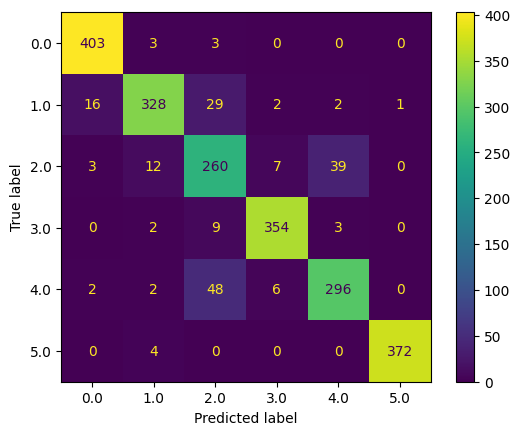

The best score achieved was:  0.9874390913778631  with k = 5

--- Using 10 Features ----
              precision    recall  f1-score   support

         0.0       0.98      0.99      0.98       409
         1.0       0.97      0.98      0.97       378
         2.0       0.84      0.87      0.85       321
         3.0       1.00      0.98      0.99       368
         4.0       0.89      0.86      0.88       354
         5.0       1.00      0.99      1.00       376

    accuracy                           0.95      2206
   macro avg       0.94      0.94      0.94      2206
weighted avg       0.95      0.95      0.95      2206

ROC-AUC: 0.9938048228213848


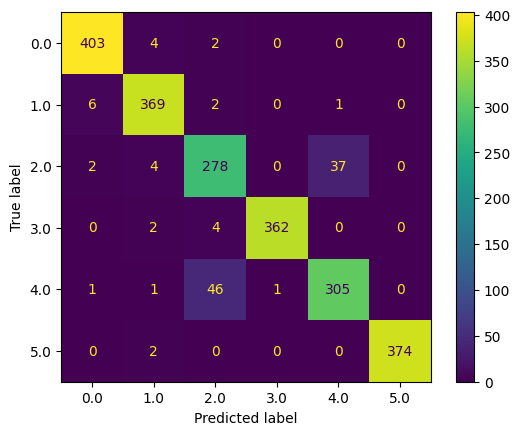

The best score achieved was:  0.9938048228213848  with k = 10

--- Using 15 Features ----
              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99       409
         1.0       0.97      0.99      0.98       378
         2.0       0.91      0.96      0.93       321
         3.0       1.00      0.98      0.99       368
         4.0       0.96      0.92      0.94       354
         5.0       1.00      0.99      1.00       376

    accuracy                           0.97      2206
   macro avg       0.97      0.97      0.97      2206
weighted avg       0.97      0.97      0.97      2206

ROC-AUC: 0.9989526054838113


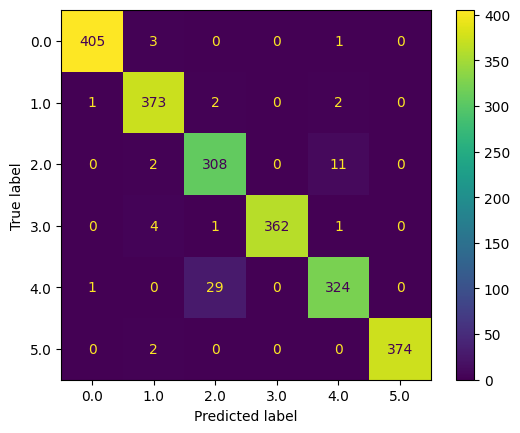

The best score achieved was:  0.9989526054838113  with k = 15

--- Using 20 Features ----
              precision    recall  f1-score   support

         0.0       0.99      0.98      0.99       409
         1.0       0.97      0.99      0.98       378
         2.0       0.92      0.97      0.94       321
         3.0       1.00      0.99      0.99       368
         4.0       0.96      0.92      0.94       354
         5.0       1.00      0.99      1.00       376

    accuracy                           0.97      2206
   macro avg       0.97      0.97      0.97      2206
weighted avg       0.98      0.97      0.97      2206

ROC-AUC: 0.9992229337728098


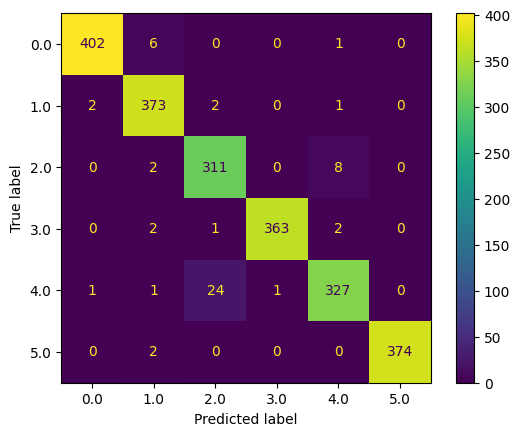

The best score achieved was:  0.9992229337728098  with k = 20

--- Using 25 Features ----
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99       409
         1.0       0.97      0.98      0.98       378
         2.0       0.95      0.97      0.96       321
         3.0       1.00      0.99      0.99       368
         4.0       0.97      0.96      0.97       354
         5.0       1.00      0.99      1.00       376

    accuracy                           0.98      2206
   macro avg       0.98      0.98      0.98      2206
weighted avg       0.98      0.98      0.98      2206

ROC-AUC: 0.9995957037470468


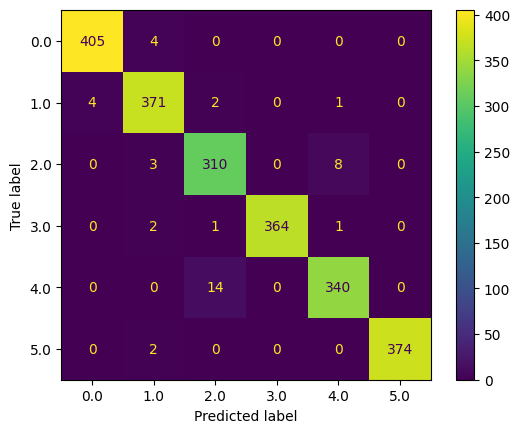

The best score achieved was:  0.9995957037470468  with k = 25

--- Using 30 Features ----
              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99       409
         1.0       0.98      0.98      0.98       378
         2.0       0.95      0.98      0.96       321
         3.0       1.00      0.99      0.99       368
         4.0       0.98      0.96      0.97       354
         5.0       1.00      0.99      1.00       376

    accuracy                           0.98      2206
   macro avg       0.98      0.98      0.98      2206
weighted avg       0.98      0.98      0.98      2206

ROC-AUC: 0.9996713137706096


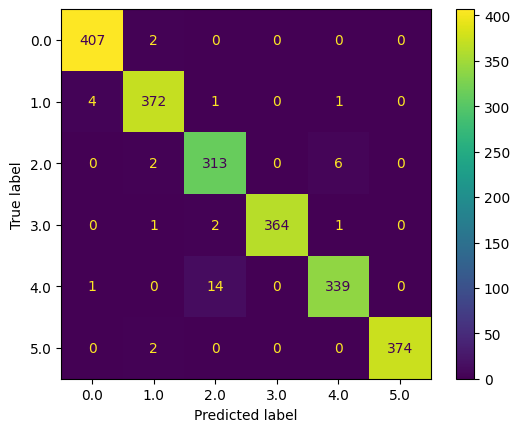

The best score achieved was:  0.9996713137706096  with k = 30

--- Using 35 Features ----
              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99       409
         1.0       0.98      0.99      0.98       378
         2.0       0.96      0.98      0.97       321
         3.0       1.00      0.99      0.99       368
         4.0       0.98      0.97      0.98       354
         5.0       1.00      0.99      1.00       376

    accuracy                           0.99      2206
   macro avg       0.98      0.99      0.98      2206
weighted avg       0.99      0.99      0.99      2206

ROC-AUC: 0.9997197096950458


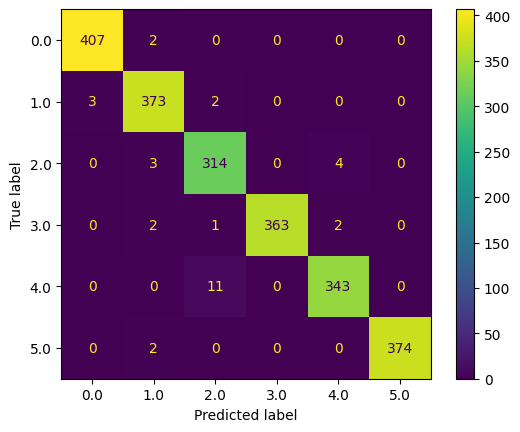

The best score achieved was:  0.9997197096950458  with k = 35

--- Using 40 Features ----
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       409
         1.0       0.98      0.99      0.98       378
         2.0       0.96      0.97      0.97       321
         3.0       1.00      0.99      1.00       368
         4.0       0.98      0.97      0.97       354
         5.0       1.00      0.99      1.00       376

    accuracy                           0.99      2206
   macro avg       0.99      0.99      0.99      2206
weighted avg       0.99      0.99      0.99      2206

ROC-AUC: 0.9997821786070594


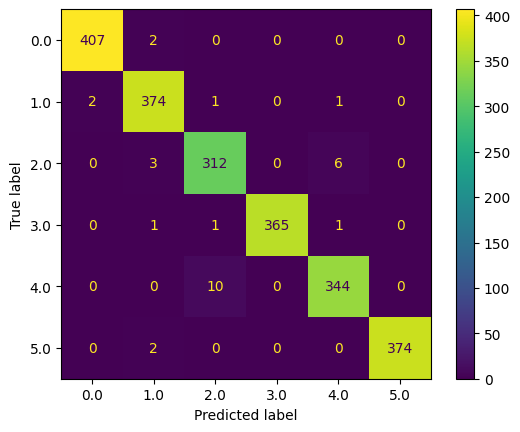

The best score achieved was:  0.9997821786070594  with k = 40

--- Using 45 Features ----
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       409
         1.0       0.98      0.99      0.98       378
         2.0       0.99      0.99      0.99       321
         3.0       1.00      0.99      0.99       368
         4.0       0.99      1.00      1.00       354
         5.0       1.00      0.99      1.00       376

    accuracy                           0.99      2206
   macro avg       0.99      0.99      0.99      2206
weighted avg       0.99      0.99      0.99      2206

ROC-AUC: 0.9998936201826369


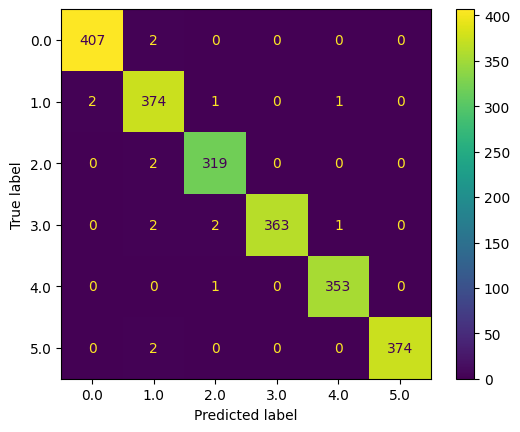

The best score achieved was:  0.9998936201826369  with k = 45

--- Using 50 Features ----
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99       409
         1.0       0.98      0.99      0.98       378
         2.0       0.98      0.99      0.99       321
         3.0       1.00      0.99      0.99       368
         4.0       0.99      0.99      0.99       354
         5.0       1.00      0.99      1.00       376

    accuracy                           0.99      2206
   macro avg       0.99      0.99      0.99      2206
weighted avg       0.99      0.99      0.99      2206

ROC-AUC: 0.9996410304872806


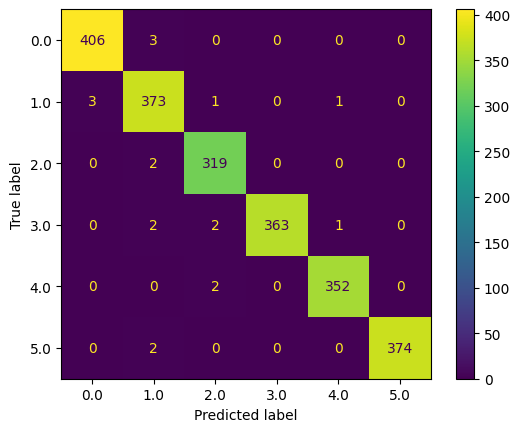

The best score achieved was:  0.9998936201826369  with k = 45

--- Using 55 Features ----
              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99       409
         1.0       0.98      0.99      0.98       378
         2.0       0.99      0.99      0.99       321
         3.0       1.00      0.99      0.99       368
         4.0       0.99      1.00      1.00       354
         5.0       1.00      0.99      1.00       376

    accuracy                           0.99      2206
   macro avg       0.99      0.99      0.99      2206
weighted avg       0.99      0.99      0.99      2206

ROC-AUC: 0.9999058363978981


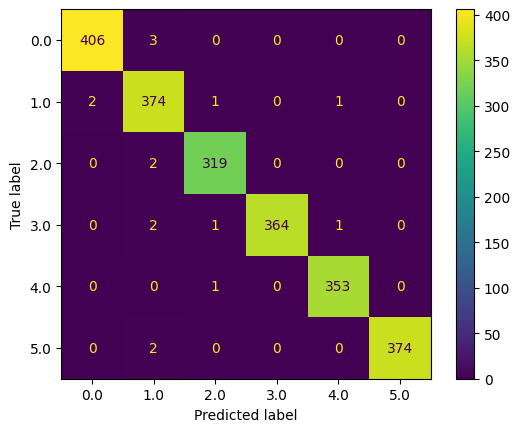

The best score achieved was:  0.9999058363978981  with k = 55

--- Using 60 Features ----
              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99       409
         1.0       0.98      0.99      0.98       378
         2.0       0.99      0.99      0.99       321
         3.0       1.00      0.99      0.99       368
         4.0       0.99      1.00      1.00       354
         5.0       1.00      0.99      1.00       376

    accuracy                           0.99      2206
   macro avg       0.99      0.99      0.99      2206
weighted avg       0.99      0.99      0.99      2206

ROC-AUC: 0.9999178722708333


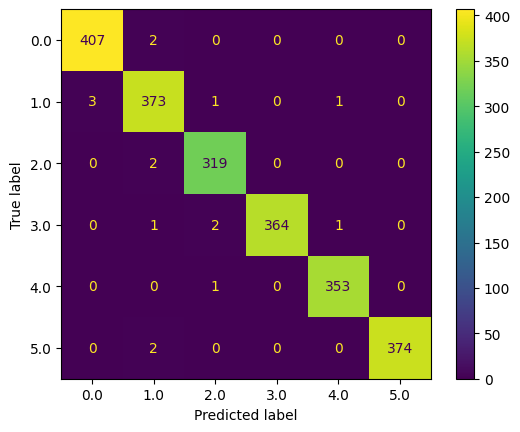

The best score achieved was:  0.9999178722708333  with k = 60

--- Using 65 Features ----
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99       409
         1.0       0.98      0.99      0.98       378
         2.0       0.99      0.99      0.99       321
         3.0       1.00      0.99      1.00       368
         4.0       0.99      1.00      1.00       354
         5.0       1.00      0.99      1.00       376

    accuracy                           0.99      2206
   macro avg       0.99      0.99      0.99      2206
weighted avg       0.99      0.99      0.99      2206

ROC-AUC: 0.999690867555442


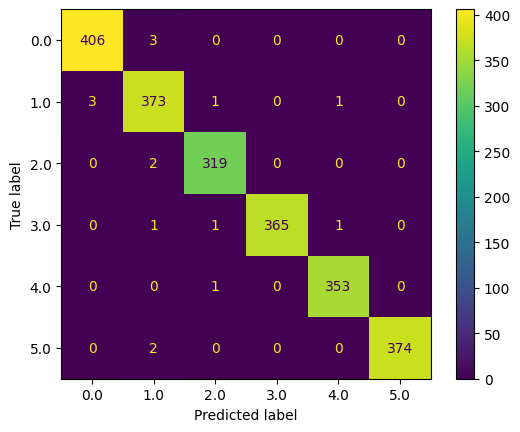

The best score achieved was:  0.9999178722708333  with k = 60

--- Using 70 Features ----
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       409
         1.0       0.99      0.99      0.99       378
         2.0       0.99      1.00      0.99       321
         3.0       1.00      0.99      0.99       368
         4.0       0.99      1.00      1.00       354
         5.0       1.00      0.99      1.00       376

    accuracy                           0.99      2206
   macro avg       0.99      0.99      0.99      2206
weighted avg       0.99      0.99      0.99      2206

ROC-AUC: 0.9999307935097304


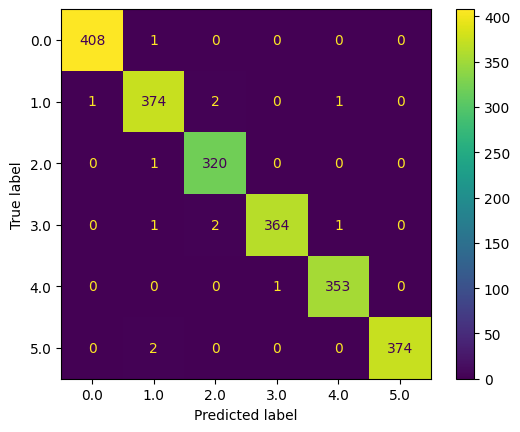

The best score achieved was:  0.9999307935097304  with k = 70

--- Using 75 Features ----
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       409
         1.0       0.99      0.99      0.99       378
         2.0       0.99      1.00      1.00       321
         3.0       1.00      0.99      1.00       368
         4.0       0.99      1.00      1.00       354
         5.0       1.00      0.99      1.00       376

    accuracy                           0.99      2206
   macro avg       0.99      0.99      0.99      2206
weighted avg       0.99      0.99      0.99      2206

ROC-AUC: 0.999935536901007


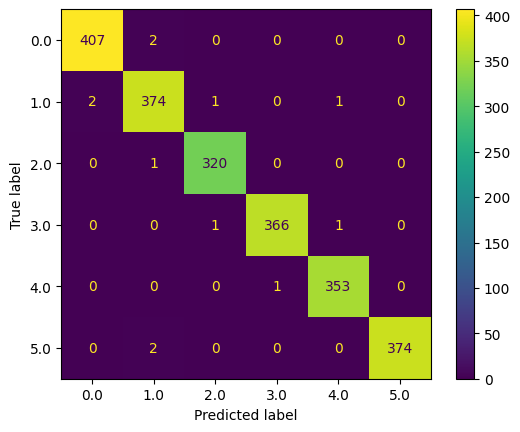

The best score achieved was:  0.999935536901007  with k = 75

--- Using 80 Features ----
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       409
         1.0       0.98      0.99      0.98       378
         2.0       0.99      0.99      0.99       321
         3.0       1.00      0.99      0.99       368
         4.0       1.00      0.99      1.00       354
         5.0       1.00      0.99      1.00       376

    accuracy                           0.99      2206
   macro avg       0.99      0.99      0.99      2206
weighted avg       0.99      0.99      0.99      2206

ROC-AUC: 0.9999316722329724


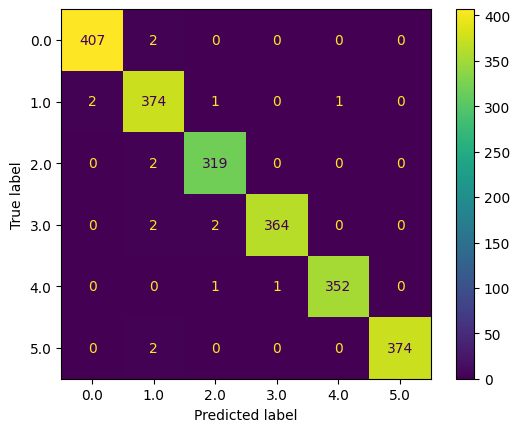

The best score achieved was:  0.999935536901007  with k = 75

--- Using 85 Features ----
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       409
         1.0       0.98      0.99      0.99       378
         2.0       0.99      0.99      0.99       321
         3.0       1.00      0.99      1.00       368
         4.0       1.00      1.00      1.00       354
         5.0       1.00      0.99      1.00       376

    accuracy                           0.99      2206
   macro avg       0.99      0.99      0.99      2206
weighted avg       0.99      0.99      0.99      2206

ROC-AUC: 0.9999247084552426


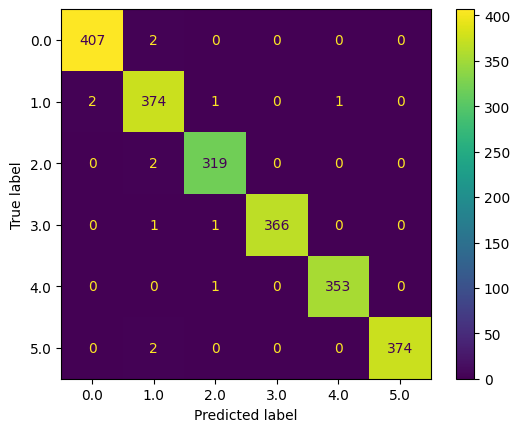

The best score achieved was:  0.999935536901007  with k = 75

--- Using 90 Features ----
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       409
         1.0       0.98      0.99      0.98       378
         2.0       0.99      0.99      0.99       321
         3.0       1.00      0.99      1.00       368
         4.0       1.00      0.99      1.00       354
         5.0       1.00      0.99      1.00       376

    accuracy                           0.99      2206
   macro avg       0.99      0.99      0.99      2206
weighted avg       0.99      0.99      0.99      2206

ROC-AUC: 0.9999476269707772


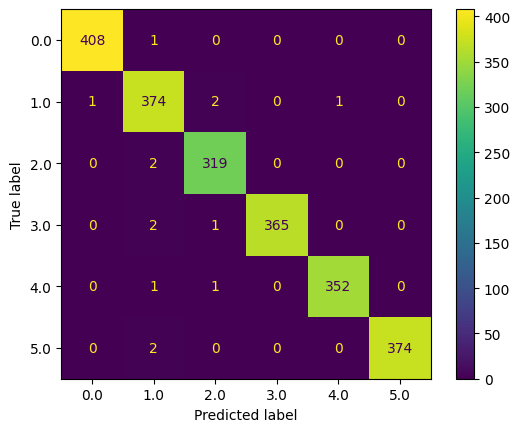

The best score achieved was:  0.9999476269707772  with k = 90

--- Using 95 Features ----
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       409
         1.0       0.98      0.99      0.99       378
         2.0       0.99      1.00      0.99       321
         3.0       1.00      0.99      1.00       368
         4.0       1.00      0.99      1.00       354
         5.0       1.00      0.99      1.00       376

    accuracy                           0.99      2206
   macro avg       0.99      0.99      0.99      2206
weighted avg       0.99      0.99      0.99      2206

ROC-AUC: 0.9999561001162357


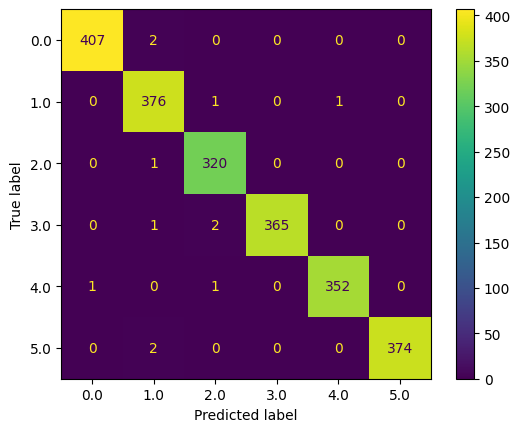

The best score achieved was:  0.9999561001162357  with k = 95

--- Using 100 Features ----
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       409
         1.0       0.98      0.99      0.99       378
         2.0       0.99      1.00      0.99       321
         3.0       1.00      0.99      1.00       368
         4.0       1.00      0.99      1.00       354
         5.0       1.00      0.99      1.00       376

    accuracy                           0.99      2206
   macro avg       0.99      0.99      0.99      2206
weighted avg       0.99      0.99      0.99      2206

ROC-AUC: 0.9999426770831529


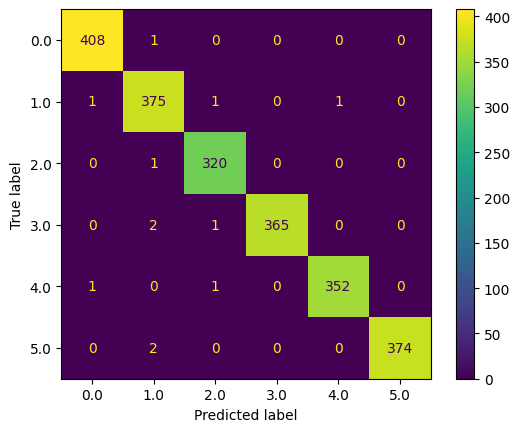

The best score achieved was:  0.9999561001162357  with k = 95

--- Using 105 Features ----
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       409
         1.0       0.98      0.99      0.98       378
         2.0       0.99      0.99      0.99       321
         3.0       1.00      0.99      0.99       368
         4.0       1.00      0.99      1.00       354
         5.0       1.00      0.99      1.00       376

    accuracy                           0.99      2206
   macro avg       0.99      0.99      0.99      2206
weighted avg       0.99      0.99      0.99      2206

ROC-AUC: 0.9999526118304051


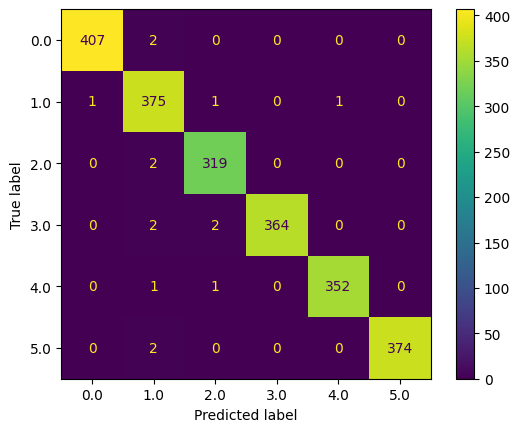

The best score achieved was:  0.9999561001162357  with k = 95

--- Using 110 Features ----
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       409
         1.0       0.98      0.99      0.99       378
         2.0       0.98      1.00      0.99       321
         3.0       1.00      0.99      0.99       368
         4.0       1.00      0.99      1.00       354
         5.0       1.00      0.99      1.00       376

    accuracy                           0.99      2206
   macro avg       0.99      0.99      0.99      2206
weighted avg       0.99      0.99      0.99      2206

ROC-AUC: 0.9999387814333547


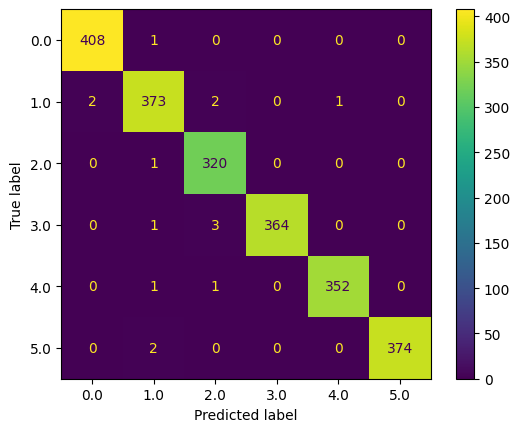

The best score achieved was:  0.9999561001162357  with k = 95

--- Using 115 Features ----
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       409
         1.0       0.98      0.99      0.98       378
         2.0       0.99      0.99      0.99       321
         3.0       1.00      0.99      0.99       368
         4.0       1.00      1.00      1.00       354
         5.0       1.00      0.99      1.00       376

    accuracy                           0.99      2206
   macro avg       0.99      0.99      0.99      2206
weighted avg       0.99      0.99      0.99      2206

ROC-AUC: 0.9999549910894276


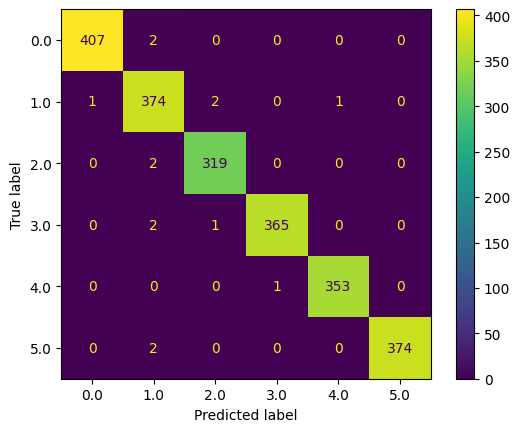

The best score achieved was:  0.9999561001162357  with k = 95

--- Using 120 Features ----
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       409
         1.0       0.98      0.99      0.99       378
         2.0       0.99      1.00      0.99       321
         3.0       1.00      0.99      0.99       368
         4.0       1.00      1.00      1.00       354
         5.0       1.00      0.99      1.00       376

    accuracy                           0.99      2206
   macro avg       0.99      0.99      0.99      2206
weighted avg       0.99      0.99      0.99      2206

ROC-AUC: 0.9999586336309093


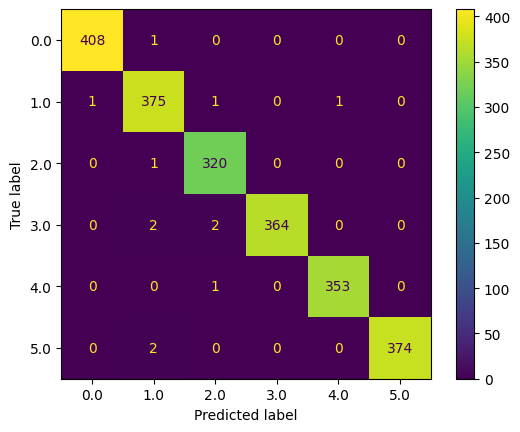

The best score achieved was:  0.9999586336309093  with k = 120


/Users/diegopez/Library/Python/3.9/lib/python/site-packages/sklearn/feature_selection/_univariate_selection.py:783: UserWarning: k=125 is greater than n_features=122. All the features will be returned.
  warnings.warn(



--- Using 125 Features ----
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       409
         1.0       0.98      0.99      0.99       378
         2.0       0.98      1.00      0.99       321
         3.0       1.00      0.99      0.99       368
         4.0       1.00      0.99      0.99       354
         5.0       1.00      0.99      1.00       376

    accuracy                           0.99      2206
   macro avg       0.99      0.99      0.99      2206
weighted avg       0.99      0.99      0.99      2206

ROC-AUC: 0.9999602810874634


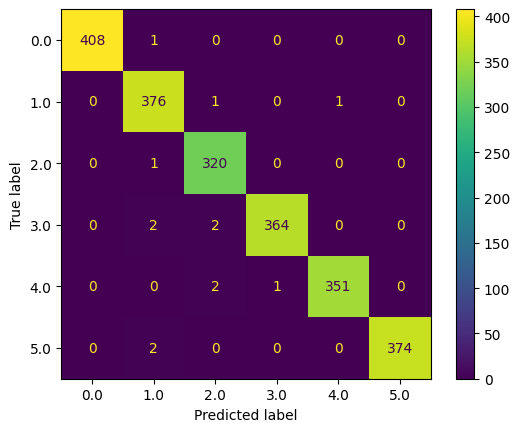

The best score achieved was:  0.9999602810874634  with k = 125


/Users/diegopez/Library/Python/3.9/lib/python/site-packages/sklearn/feature_selection/_univariate_selection.py:783: UserWarning: k=130 is greater than n_features=122. All the features will be returned.
  warnings.warn(



--- Using 130 Features ----
              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99       409
         1.0       0.98      0.99      0.98       378
         2.0       0.99      0.99      0.99       321
         3.0       1.00      0.99      0.99       368
         4.0       1.00      1.00      1.00       354
         5.0       1.00      1.00      1.00       376

    accuracy                           0.99      2206
   macro avg       0.99      0.99      0.99      2206
weighted avg       0.99      0.99      0.99      2206

ROC-AUC: 0.9999229670821124


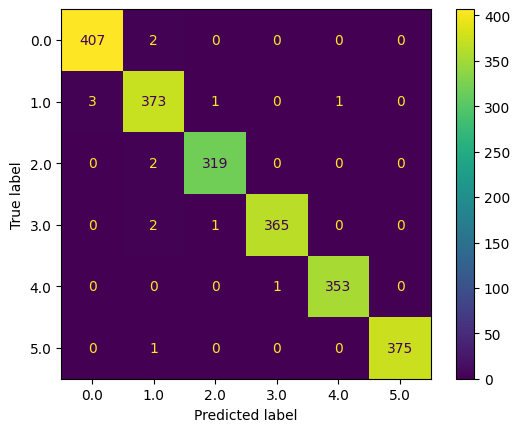

The best score achieved was:  0.9999602810874634  with k = 125


In [29]:
# Sklearn Imports
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Test Train Split (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42)

best_k = 0
best_score = 0
for i in range(5, X_train.shape[1], 5):
    pipeline = Pipeline([
        ('variance', VarianceThreshold(threshold=0.0)),
        ('selector', SelectKBest(f_classif, k=i)),
        ('random_forest', RandomForestClassifier())
    ])

    pipeline.fit(X_train, y_train)
    prediction = pipeline.predict(X_test)
    probability = pipeline.predict_proba(X_test)

    print(f"\n--- Using {i} Features ----")
    print(classification_report(y_test, prediction))

    roc_auc = roc_auc_score(y_test, probability, multi_class='ovr')
    print("ROC-AUC:",
          roc_auc)

    if best_score < roc_auc:
        best_score = roc_auc
        best_k = i

    cm = confusion_matrix(
        y_test,
        prediction,
        labels=pipeline.named_steps['random_forest'].classes_
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=pipeline.named_steps['random_forest'].classes_
    )

    disp.plot()
    plt.show()

    print("The best score achieved was: ", best_score, " with k =", best_k)

I think I got it, actually with 5 misserable features this model was really accurate, I mean it makes sense since the gestures features are broken and make most of the work, but the model becoming a 99.99% accurate with more extra features was absoulte cinema

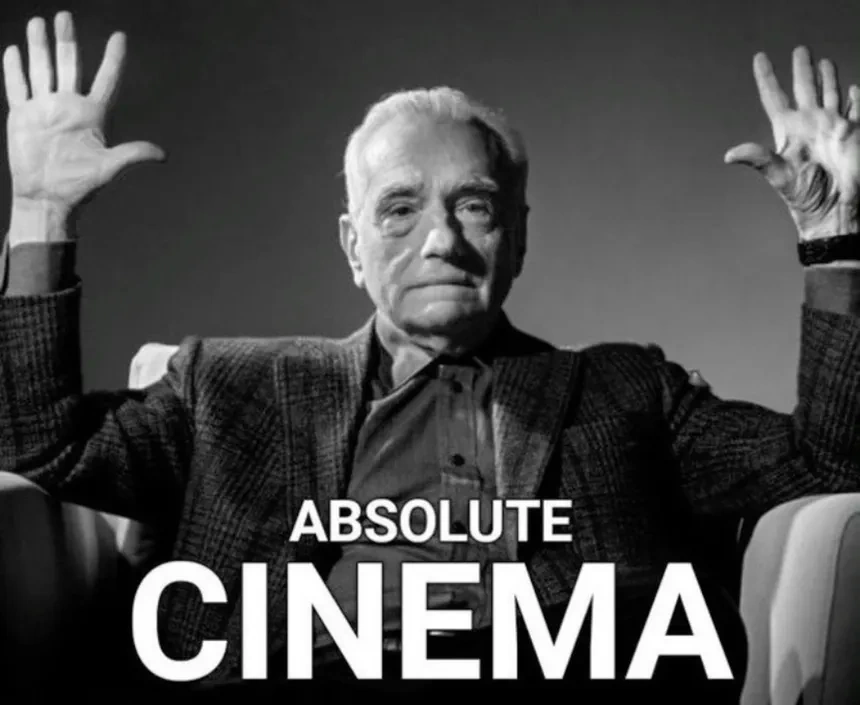

This as a initial Landmark seems to be actually finished work but I will try to level up my game trying to use XGBoost to make a better model using the 120 significant features and actually most of the features were important!

### XGBoost
Just doing it because I can, and I want, I wont even train a data set significant enough for this to be useful or maybe I will

In [34]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

param_grid = {
    'selector__k': [120],
    'xgb__n_estimators': [100, 200],
    'xgb__max_depth': [3, 4, 5],
    'xgb__learning_rate': [0.05, 0.1, 0.2],
    'xgb__subsample': [0.8, 1.0],
    'xgb__colsample_bytree': [0.8, 1.0]
}

xgb_pipeline = Pipeline([
    ('variance', VarianceThreshold(threshold=0.0)),
    ('selector', SelectKBest(f_classif)),
    ('xgb', XGBClassifier(
        objective='multi:softprob',
        eval_metric='mlogloss',
        random_state=42
    ))
])

grid = GridSearchCV(
    xgb_pipeline,
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('variance', VarianceThreshold()),
                                       ('selector', SelectKBest()),
                                       ('xgb',
                                        XGBClassifier(base_score=None,
                                                      booster=None,
                                                      callbacks=None,
                                                      colsample_bylevel=None,
                                                      colsample_bynode=None,
                                                      colsample_bytree=None,
                                                      device=None,
                                                      early_stopping_rounds=None,
                                                      enable_categorical=False,
                                                      eval_metric='mlogloss',
                                                      feature_types=None,
                                                      gamma=No...
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None,
                                                      objective='multi:softprob', ...))]),
             n_jobs=-1,
             param_grid={'selector__k': [120],
                         'xgb__colsample_bytree': [0.8, 1.0],
                         'xgb__learning_rate': [0.05, 0.1, 0.2],
                         'xgb__max_depth': [3, 4, 5],
                         'xgb__n_estimators': [100, 200],
                         'xgb__subsample': [0.8, 1.0]},
             scoring='accuracy')

Best Params: {'selector__k': 120, 'xgb__colsample_bytree': 1.0, 'xgb__learning_rate': 0.2, 'xgb__max_depth': 3, 'xgb__n_estimators': 200, 'xgb__subsample': 1.0}
Best Score: 0.993003481778992
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       409
         1.0       0.99      0.99      0.99       378
         2.0       0.99      1.00      0.99       321
         3.0       1.00      0.99      0.99       368
         4.0       0.99      0.99      0.99       354
         5.0       1.00      0.99      1.00       376

    accuracy                           0.99      2206
   macro avg       0.99      0.99      0.99      2206
weighted avg       0.99      0.99      0.99      2206

ROC-AUC: 0.9999613162226523


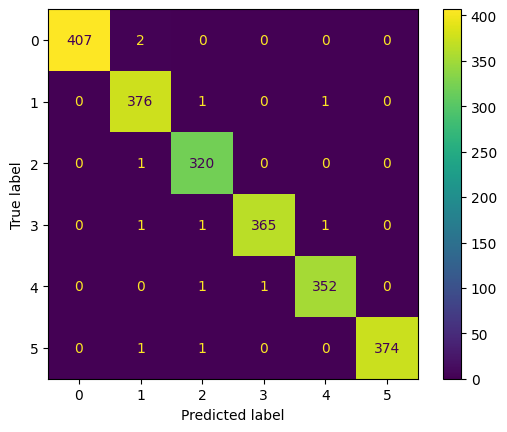

In [39]:
print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

grid_prediction = grid.predict(X_test)
grid_probability = grid.predict_proba(X_test)

print(classification_report(y_test, grid_prediction))

grid_roc_auc = roc_auc_score(y_test, grid_probability, multi_class='ovr')
print("ROC-AUC:", grid_roc_auc)

cm = confusion_matrix(
    y_test,
    grid_prediction,
    labels=grid.best_estimator_.named_steps['xgb'].classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=grid.best_estimator_.named_steps['xgb'].classes_
)

disp.plot()
plt.show()


All this problem just to go from 99.9960% to 99.9961% ROC-AUC
Just to flex in my resume I will use XGBoost model, but there is no significant difference

### Export Final Pipeline

In [41]:
import joblib
joblib.dump(grid, "emote_detection_pipeline.pkl")

['emote_detection_pipeline.pkl']